# Task 1. Which year had the highest amount of crimes?

In [ ]:
%%bigquery
SELECT
  EXTRACT(YEAR FROM `Date`) AS year,
  COUNT(*) AS n_crimes
FROM `alva-coding-test.chicago_crime.crime`
GROUP BY year
ORDER BY n_crimes
DESC LIMIT 1  -- 5

Query is running:   0%|          |

Downloading:   0%|          |

,year,n_crimes
0,2002,486825


# Task 2. Arrest Rate

Let's define "Arrest Rate" as the share of crimes that led to an arrest.

What year had the highest arrest rate?

What is the overall trend in number of crimes per year?

## Arrest rate per year

In [ ]:
%%bigquery
SELECT
  EXTRACT(YEAR FROM `Date`) AS year,
  COUNT(*) AS n_crimes, COUNT(CASE WHEN `arrest` = TRUE THEN 1 END) AS ARRESTED_COUNT,
  COUNT(CASE WHEN `arrest` = FALSE THEN 1 END) AS NON_ARRESTED_COUNT,
  AVG(CAST(arrest AS INT64)) AS ARREST_RATE
FROM `alva-coding-test.chicago_crime.crime`
GROUP BY year
ORDER BY year;

Query is running:   0%|          |

Downloading:   0%|          |

,year,n_crimes,ARRESTED_COUNT,NON_ARRESTED_COUNT,ARREST_RATE
0,2001,485920,141942,343978,0.292110
1,2002,486825,141578,345247,0.290819
2,2003,475989,141600,334389,0.297486
3,2004,469432,144704,324728,0.308253
4,2005,453779,140928,312851,0.310565
5,2006,448191,135426,312765,0.302161
6,2007,437093,131881,305212,0.301723
7,2008,427196,110026,317170,0.257554
8,2009,392842,110840,282002,0.282149
9,2010,370540,100554,269986,0.271372


## Year with the highest arrest rate

In [ ]:
%%bigquery
SELECT
  EXTRACT(YEAR FROM `Date`) AS year,
  AVG(CAST(arrest AS INT64)) AS ARREST_RATE
FROM `alva-coding-test.chicago_crime.crime`
GROUP BY year
ORDER BY ARREST_RATE DESC
LIMIT 1

Query is running:   0%|          |

Downloading:   0%|          |

,year,ARREST_RATE
0,2005,0.310565


## Overall trend in number of crimes per year

In [ ]:
%%bigquery df2
-- Save in a df2 dataframe
SELECT
  EXTRACT(YEAR FROM `Date`) as year,
  AVG(CAST(arrest AS INT64)) AS ARREST_RATE
FROM `alva-coding-test.chicago_crime.crime`
GROUP BY year
ORDER BY year

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
display(df2)  # we've already seen it as a table, now as a dataframe

,year,ARREST_RATE
0,2001,0.292110
1,2002,0.290819
2,2003,0.297486
3,2004,0.308253
4,2005,0.310565
5,2006,0.302161
6,2007,0.301723
7,2008,0.257554
8,2009,0.282149
9,2010,0.271372


## Plot the trend of the arrest rate - note the overall declining rate

In [ ]:
# For Python graphics/diagrams
!pip install matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import sklearn  # same as scikit-learn
# import scipy.stats as stats

<Axes: xlabel='year', ylabel='ARREST_RATE'>

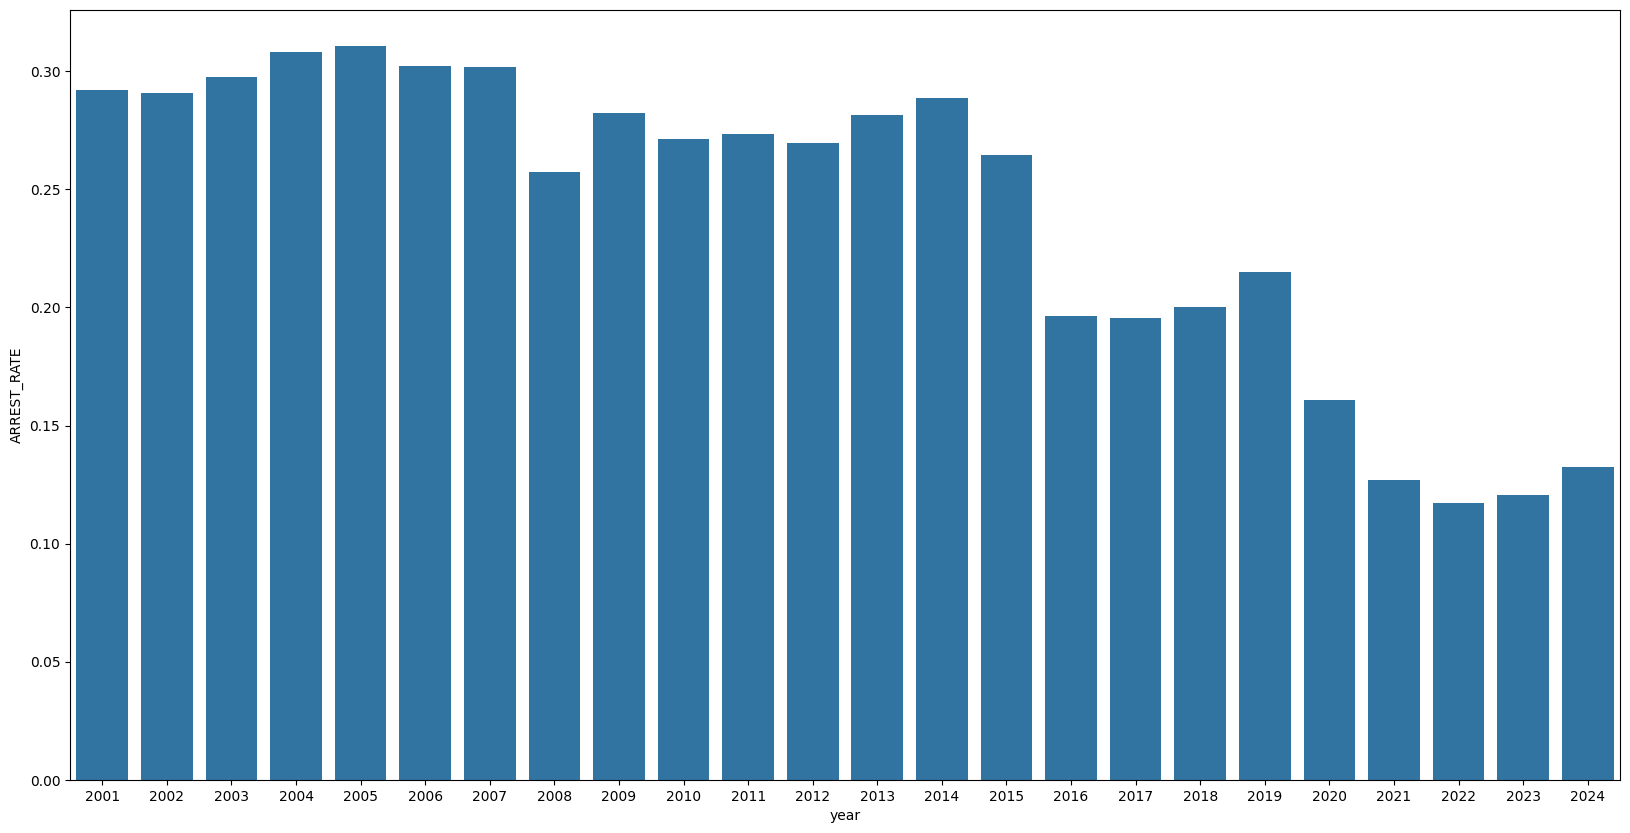

In [ ]:
plt.figure(figsize=(20, 10))
sns.barplot(x="year", y="ARREST_RATE", data=df2)

## Trend in the number of crimes

In [ ]:
%%bigquery df2a
SELECT
  EXTRACT(YEAR FROM `Date`) as year,
  COUNT(*) AS n_crimes
FROM `alva-coding-test.chicago_crime.crime`
GROUP BY year
ORDER BY year

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
display(df2a)

,year,n_crimes
0,2001,485920
1,2002,486825
2,2003,475989
3,2004,469432
4,2005,453779
5,2006,448191
6,2007,437093
7,2008,427196
8,2009,392842
9,2010,370540


## Number of crimes per year declines

<Axes: xlabel='year', ylabel='n_crimes'>

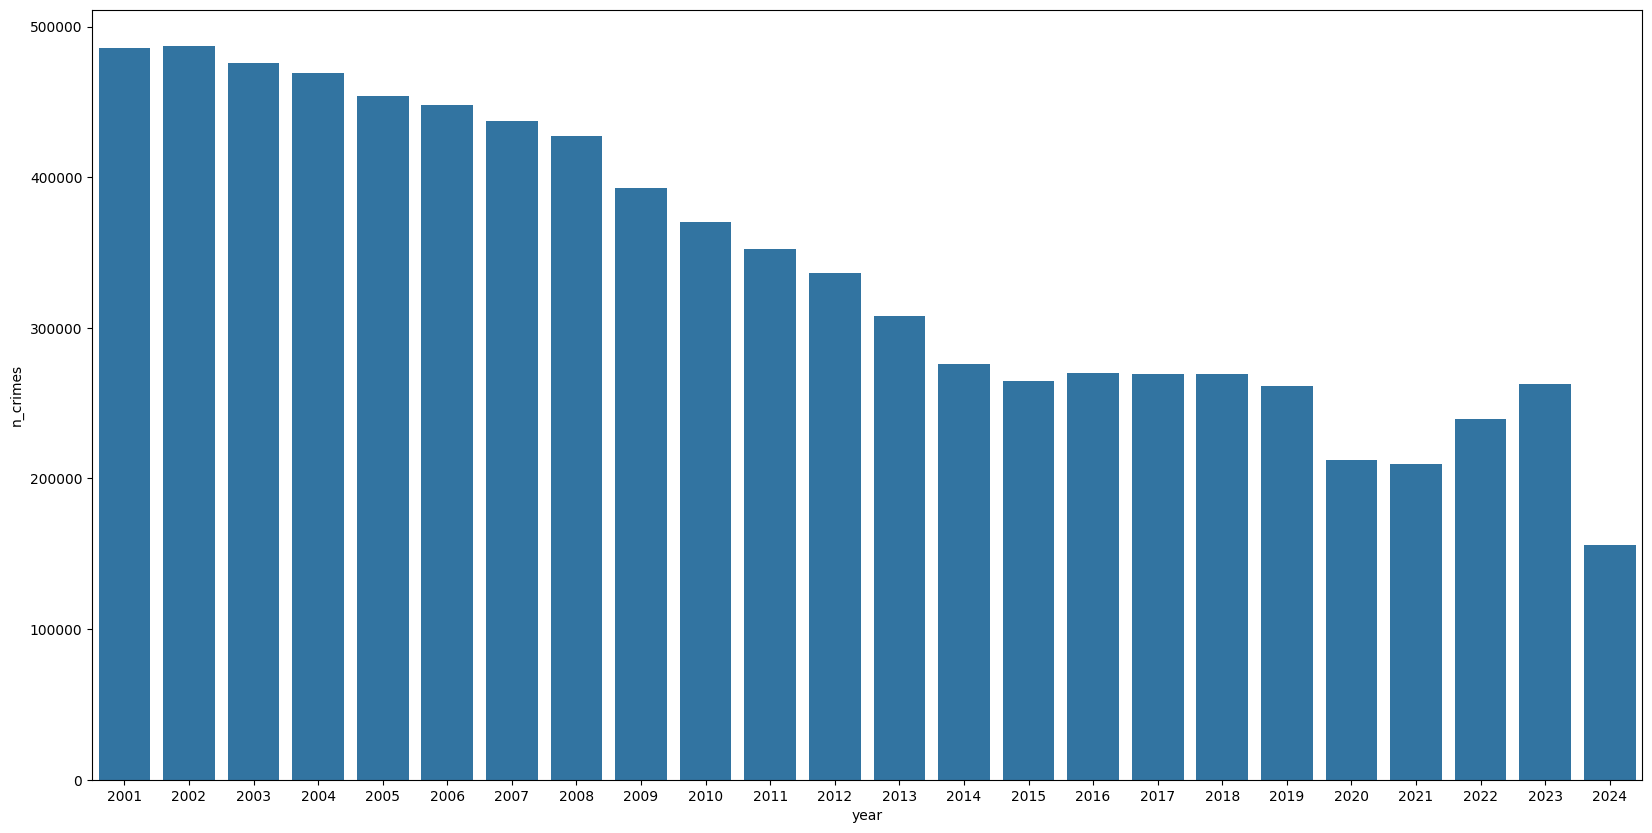

In [ ]:
plt.figure(figsize=(20, 10))
sns.barplot(x="year", y="n_crimes", data=df2a)

# Task 3. What were the five most common crimes in 2020?

Which of those crimes had the highest and lowest arrest rate?

In [ ]:
%%bigquery
SELECT
  `primary_type`,
  COUNT(*) AS CRIME_COUNT,
  AVG(CAST(arrest AS INT64)) AS ARREST_RATE
FROM `alva-coding-test.chicago_crime.crime`
WHERE EXTRACT(YEAR FROM `Date`) = 2020
GROUP BY `primary_type`
ORDER BY CRIME_COUNT
DESC LIMIT 5;

Query is running:   0%|          |

Downloading:   0%|          |

,primary_type,CRIME_COUNT,ARREST_RATE
0,BATTERY,41514,0.166691
1,THEFT,41337,0.067833
2,CRIMINAL DAMAGE,24877,0.047393
3,DECEPTIVE PRACTICE,18487,0.020825
4,ASSAULT,18257,0.127677


## Simultaneous top 5 and Min/Max arrest rates among them

In [ ]:
%%bigquery
WITH top_5_crimes AS (
  SELECT
    `primary_type`,
    COUNT(*) AS CRIME_COUNT,
    AVG(CAST(arrest AS INT64)) AS ARREST_RATE
  FROM `bigquery-public-data.chicago_crime.crime`
  WHERE EXTRACT(YEAR FROM `Date`) = 2020
  GROUP BY `primary_type`
  ORDER BY CRIME_COUNT DESC
  LIMIT 5
)

SELECT *, 'TOP_5' AS Legend
FROM top_5_crimes

UNION ALL

SELECT * FROM (
  (SELECT *, 'MIN_ARREST_RATE' AS Legend FROM top_5_crimes ORDER BY ARREST_RATE ASC LIMIT 1)
  UNION ALL
  (SELECT *, 'MAX_ARREST_RATE' AS Legend FROM top_5_crimes ORDER BY ARREST_RATE DESC LIMIT 1)
)
ORDER BY legend DESC; -- put TOP_5 first first

Query is running:   0%|          |

Downloading:   0%|          |

,primary_type,CRIME_COUNT,ARREST_RATE,Legend
0,BATTERY,41519,0.166863,TOP_5
1,THEFT,41355,0.067803,TOP_5
2,CRIMINAL DAMAGE,24882,0.047464,TOP_5
3,DECEPTIVE PRACTICE,18634,0.020876,TOP_5
4,ASSAULT,18260,0.127711,TOP_5
5,DECEPTIVE PRACTICE,18634,0.020876,MIN_ARREST_RATE
6,BATTERY,41519,0.166863,MAX_ARREST_RATE


# Task 4. How has the arrest rate looked like over time?

Plot the trend of the arrest rate.

Between which years can you see the biggest change in "Arrest Rate"?

Can you point at specific reasons to why the Arrest Rate dropped between those years? Comment on your conclusions.

Since the data set is constantly updating, disregard the year 2021 and later for the analysis in this question.

In [ ]:
%%bigquery df4
SELECT
  EXTRACT(YEAR FROM `Date`) as year,
  AVG(CAST(arrest AS INT64)) AS ARREST_RATE
FROM `alva-coding-test.chicago_crime.crime`
WHERE YEAR <= 2020  -- as required
GROUP BY year
ORDER BY year

Query is running:   0%|          |

Downloading:   0%|          |

## Plot the arrest rate

<Axes: xlabel='year', ylabel='ARREST_RATE'>

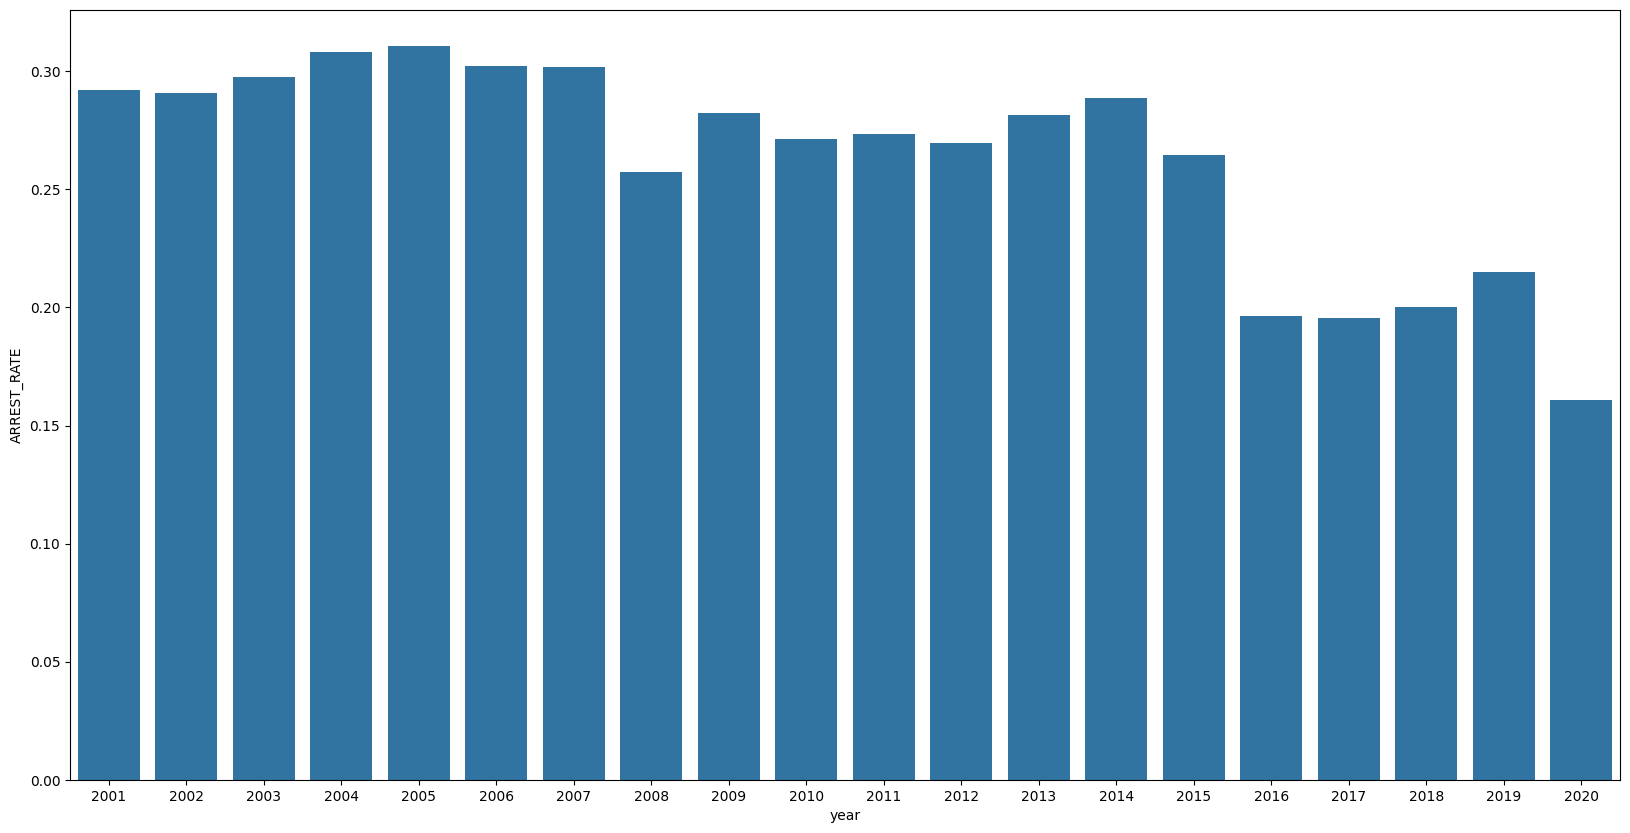

In [ ]:
plt.figure(figsize=(20, 10))
sns.barplot(x="year", y="ARREST_RATE", data=df4)

## Between which years can you see the biggest change in "Arrest Rate"?

In [ ]:
# Calculate change (this year's value minus last year's), the first/0-th is NaN as it has no predecessor
df4['CHANGE'] = df4['ARREST_RATE'].diff()
df4

,year,ARREST_RATE,CHANGE
0,2001,0.292110,NaN
1,2002,0.290819,-0.001291
2,2003,0.297486,0.006667
3,2004,0.308253,0.010768
4,2005,0.310565,0.002312
5,2006,0.302161,-0.008404
6,2007,0.301723,-0.000438
7,2008,0.257554,-0.044169
8,2009,0.282149,0.024595
9,2010,0.271372,-0.010778


## Plot the year-by-year changes

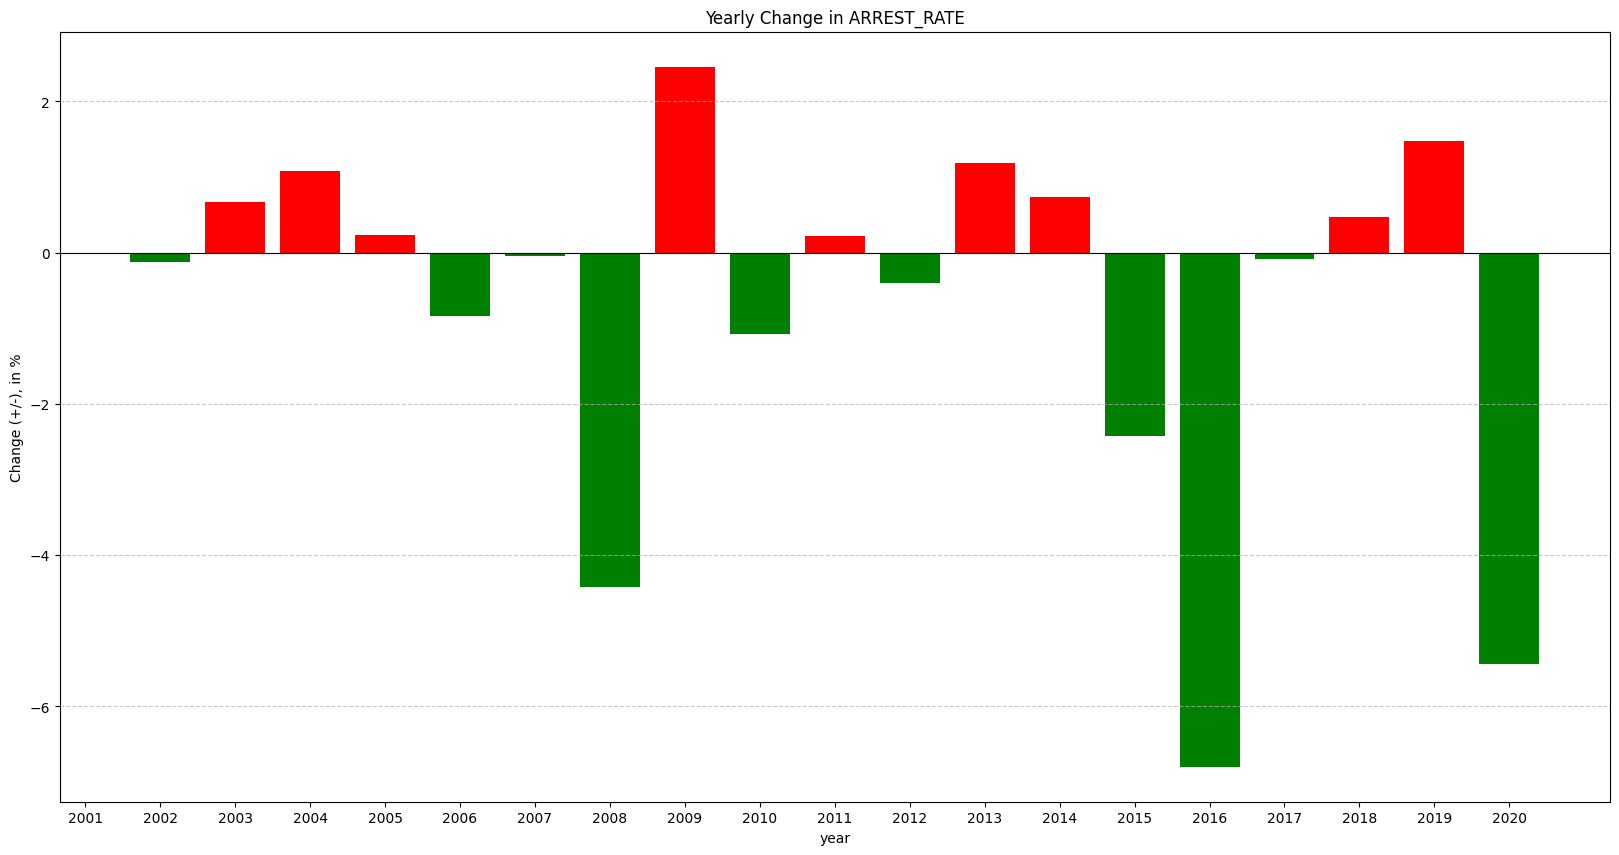

In [ ]:
plt.figure(figsize=(20, 10))
colors = ['red' if x >= 0 else 'green' for x in df4['CHANGE']]
plt.bar(df4['year'].astype(str), df4['CHANGE']*100, color=colors)  # in percent
plt.axhline(0, color='black', linewidth=0.8)  # add baseline at 0
plt.title('Yearly Change in ARREST_RATE')
plt.xlabel('year')
plt.ylabel('Change (+/-), in %')
plt.grid(axis='y', linestyle='--', alpha=0.7)

## Biggest changes (by percent points), confirms the diagram above

In [ ]:
row_min = df4.nsmallest(1, 'CHANGE')
row_max = df4.nlargest(1, 'CHANGE')
min_max_df = pd.concat([row_min, row_max])
min_max_df['Legend'] = ['MAX DECREASE', 'MAX INCREASE']
display(min_max_df)

,year,ARREST_RATE,CHANGE,Legend
15,2016,0.196539,-0.067978,MAX DECREASE
8,2009,0.282149,0.024595,MAX INCREASE


### From -6.79% to +2.45%

## Explanations:

1. The heightened arrest and incarceration
numbers in Chicago around 2009 were driven by intensive
"poverty management" strategies, such as the targeting of
specific "hot spot" areas on the city's south and west sides.
These areas saw increased number of people committed to prison sentences. Furthermore, this period was part of a
national trend, as state prison populations peaked in
2009, driven by policies like "zero tolerance" policing and
mandatory minimum sentencing.

2. The significant decrease in Chicago's arrest rate in 2016, occurring despite a sharp rise in homicides and violence, was largely driven by a reduction in proactive policing following intense scrutiny of the police department. This included the aftermath of the Laquan McDonald shooting video release (late 2015) and investigations into police misconduct, leading to a "depolicing" effect where officers were less active in making stops and arrests.


## Importand remark: what is more significant - increase by 2% from 10%, or increase by 1% from 1%? (the first is 20% relative vs second is 100% relative)

In [ ]:
# Compute relative changes:
df4['REL_CHANGE'] = df4['ARREST_RATE'].pct_change()
df4

,year,ARREST_RATE,CHANGE,REL_CHANGE
0,2001,0.292110,NaN,NaN
1,2002,0.290819,-0.001291,-0.004419
2,2003,0.297486,0.006667,0.022924
3,2004,0.308253,0.010768,0.036195
4,2005,0.310565,0.002312,0.007500
5,2006,0.302161,-0.008404,-0.027060
6,2007,0.301723,-0.000438,-0.001451
7,2008,0.257554,-0.044169,-0.146389
8,2009,0.282149,0.024595,0.095495
9,2010,0.271372,-0.010778,-0.038198


## We see the absolute and relative arrest rate changes differ substantially

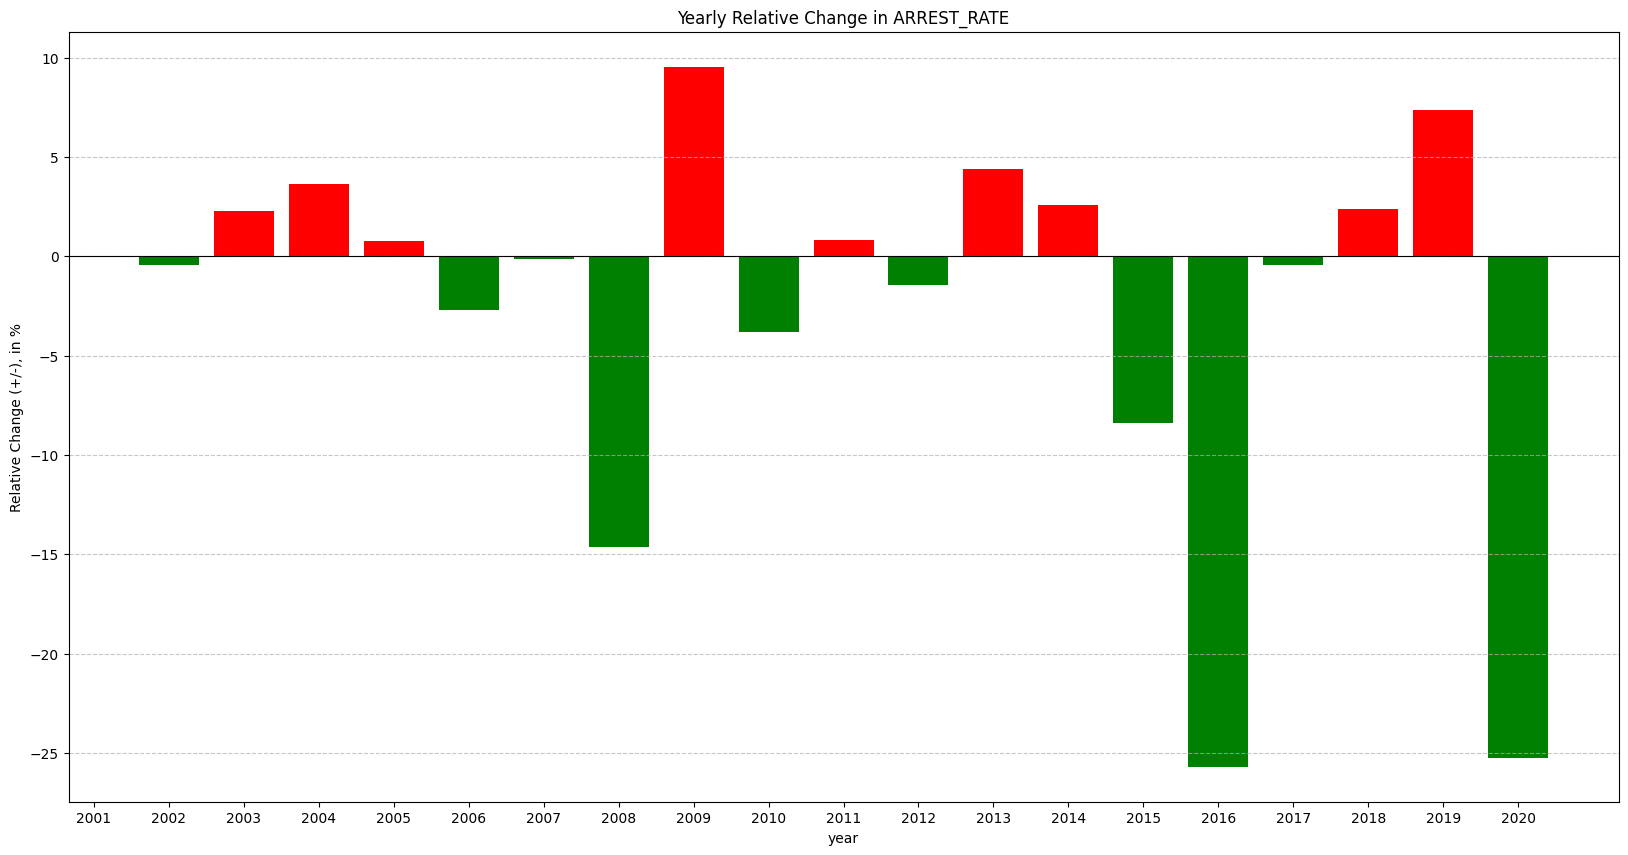

In [ ]:
plt.figure(figsize=(20, 10))
colors = ['red' if x >= 0 else 'green' for x in df4['REL_CHANGE']]
plt.bar(df4['year'].astype(str), df4['REL_CHANGE']*100, color=colors)  # in percent
plt.axhline(0, color='black', linewidth=0.8)  # add baseline at 0
plt.title('Yearly Relative Change in ARREST_RATE')
plt.xlabel('year')
plt.ylabel('Relative Change (+/-), in %')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [ ]:
row_min_r = df4.nsmallest(1, 'REL_CHANGE')
row_max_r = df4.nlargest(1, 'REL_CHANGE')
min_max_df_r = pd.concat([row_min_r, row_max_r])
min_max_df_r['Legend'] = ['MAX RELATIVE DECREASE', 'MAX RELATIVE INCREASE']
display(min_max_df_r)

,year,ARREST_RATE,CHANGE,REL_CHANGE,Legend
15,2016,0.196539,-0.067978,-0.256989,MAX RELATIVE DECREASE
8,2009,0.282149,0.024595,0.095495,MAX RELATIVE INCREASE


### From -26% to 9.5% (i.e., the relative range is BIGGER!)

# Task 5. What was the arrest rate for thefts during 2017 and 2018?

How much did the arrest rate decrease between those two years?

Perform a t-test to determine if the decrease in arrest rate is significant at

a 95% confidence level.

Comment on your conclusions.

## Decrease in theft arrest rate from 2017 to 2018:

In [ ]:
%%bigquery df5
WITH THEFT_2017_2018 AS (
  SELECT
    EXTRACT(YEAR FROM `Date`) AS year,
    AVG(CASE WHEN `arrest` = TRUE THEN 1 ELSE 0 END) AS ARREST_RATE_THEFT,
    COUNT(*) AS THEFT_COUNT,
    COUNT(CASE WHEN `arrest` = TRUE THEN 1 END) AS ARRESTED_THEFT_COUNT,
  FROM `alva-coding-test.chicago_crime.crime`
  WHERE EXTRACT(YEAR FROM `Date`) BETWEEN 2017 AND 2018 AND `primary_type` = 'THEFT'
  GROUP BY year
  ORDER BY year
)
SELECT
  year,
  THEFT_COUNT,
  ARRESTED_THEFT_COUNT,
  ARREST_RATE_THEFT,
  ARREST_RATE_THEFT - COALESCE(LAG(ARREST_RATE_THEFT) OVER (ORDER BY year), ARREST_RATE_THEFT) AS diff_arrest_rate_theft,
  -- ARRESTED_THEFT_COUNT / THEFT_COUNT AS fraction
FROM  THEFT_2017_2018
ORDER BY year

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
display(df5)

,year,THEFT_COUNT,ARRESTED_THEFT_COUNT,ARREST_RATE_THEFT,diff_arrest_rate_theft
0,2017,64386,6474,0.100550,0.000000
1,2018,65289,6339,0.097091,-0.003458


### Performing a Statistical Test on Two Rates (Proportions)

To compare two **rates** (proportions) instead of means, one typically uses a **Two-Sample Z-Test for Proportions** rather than a standard T-test.

#### 1. Why we don't need Mean or Standard Deviation?

For a rate (like an arrest rate of 0.15), the "mean" is simply the rate itself ($p$), and the variance is automatically derived from the rate and the sample size using the formula: $\text{Variance} = p \times (1 - p)$.

**Important:** To perform this test, we **must** know the sample size ($n$) for each group, i.e., total number of crimes in group X (for 2017) and group Y (for 2018).

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# As given by BigQuery table (above)
# 2017	64386	6474	0.100550
# 2018	65289	6339	0.097091
# counts = np.array([6474, 6339])  # number of thefts that led to arrests (ARRESTED_RATE_THEFT), in 2017, 2018
# nobs = np.array([64386, 65289])  # total number of thefts, in 2017, 2088
# We saved the previous query as a dataframe and can extract the numbers:

counts = np.array([int(df5['ARRESTED_THEFT_COUNT'].iloc[0]), int(df5['ARRESTED_THEFT_COUNT'].iloc[1])])  # number of thefts that led to arrests (ARRESTED_RATE_THEFT), in 2017, 2018
nobs = np.array([int(df5['THEFT_COUNT'].iloc[0]), int(df5['THEFT_COUNT'].iloc[1])])  # total number of thefts, in 2017, 2018

# Perform the Z-test
z_stat, p_value = proportions_ztest(counts, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Check for significance at 95% confidence (alpha = 0.05)
significance = 0.95
alpha = 1 - significance
print(f"Significance: {significance:.4f}, alpha: {alpha:.4f}")

if p_value < alpha:
    print("CONCLUSION: Significant difference: The rates are statistically different. We REJECT the null hypothesis (that theft arrest rates do not differ in 2017 and 2018)!!!")
else:
    print("CONCLUSION: No significant difference: The difference could be due to chance. We FAIL to REJECT the null hypothesis")
# Z-statistic: 2.0867
# P-value: 0.0369
# Significance: 0.9500, alpha: 0.0500
# CONCLUSION: Significant difference: The rates are statistically different. We REJECT the null hypothesis (that theft arrest rates do not differ in 2017 and 2018)!!!

Z-statistic: 2.0867
P-value: 0.0369
Significance: 0.9500, alpha: 0.0500
CONCLUSION: Significant difference: The rates are statistically different. We REJECT the null hypothesis (that theft arrest rates do not differ in 2017 and 2018)!!!


## Conclusion. Significant difference: The rates are statistically different. We REJECT the null hypothesis (that theft arrest rates do not differ in 2017 and 2018)!!!

# Task 6. Calculate the average number of crimes committed per day for each month.

Which month has the highest respectively lowest number of crimes per day on average?

Since the data set is constantly updating, disregard the year 2021 and later for the analysis in this question.

In [ ]:
%%bigquery
WITH YEAR_MONTH_CRIME_COUNTS AS ( -- truncate to dates to first of each month and count crimes per each
  SELECT
    DATE_TRUNC(`Date`, MONTH) AS year_month,  -- round '2023-05-15' down to '2023-05-01'
    COUNT(*) AS crime_count
  FROM `alva-coding-test.chicago_crime.crime`
  WHERE EXTRACT(YEAR FROM `Date`) <= 2020
  GROUP BY year_month
  ORDER BY year_month
),
WITH_ADDED_DAYS_COUNTS AS ( -- add number of days for each month (leap years accounted for)
  SELECT *, EXTRACT(DAY FROM LAST_DAY(DATE(`year_month`), MONTH)) AS days_in_this_month,
  FROM YEAR_MONTH_CRIME_COUNTS
),
WITH_ADDED_CRIMES_PER_DAY AS (  -- add average per day for each month
  SELECT *, crime_count / days_in_this_month AS daily_crimes
  FROM WITH_ADDED_DAYS_COUNTS
)
SELECT
  FORMAT_TIMESTAMP('%Y-%m', DATE_TRUNC(year_month, MONTH)) AS year_month, -- format YYYY-MM and add all we need
  crime_count,
  daily_crimes,
  Legend
FROM
  ((SELECT *, 'Min daily crimes' AS Legend FROM WITH_ADDED_CRIMES_PER_DAY ORDER BY daily_crimes ASC LIMIT 1)
    UNION ALL
   (SELECT *, 'Max daily crimes' AS Legend FROM WITH_ADDED_CRIMES_PER_DAY ORDER BY daily_crimes DESC LIMIT 1)
  )

Query is running:   0%|          |

Downloading:   0%|          |

,year_month,crime_count,daily_crimes,Legend
0,2002-07,46014,1484.322581,Max daily crimes
1,2020-04,12936,431.200000,Min daily crimes


## April 2020 has minimal daily crimes, July 2002 - maximum

# Task 7. Select the five most common crimes and write and SQL query that answer the following for each crime (i.e. each primary_type).

How many crimes are committed per day on average for the month with the lowest average? Which month is this?

How many crimes are committed per day on average for the month with the highest average? Which month is it?

Since the data set is constantly updating, disregard the year 2021 and later for the analysis in this question.

## Top 5 most frequent crimes

In [ ]:
%%bigquery
SELECT `primary_type`, COUNT(*) AS n_crimes
FROM `alva-coding-test.chicago_crime.crime`
WHERE EXTRACT(YEAR FROM `Date`) <= 2020
GROUP BY `primary_type`
ORDER BY n_crimes DESC
LIMIT 5

Query is running:   0%|          |

Downloading:   0%|          |

,primary_type,n_crimes
0,THEFT,1531412
1,BATTERY,1329532
2,CRIMINAL DAMAGE,826584
3,NARCOTICS,736115
4,ASSAULT,459974


## Create a reusable table function for computing MIN/MAX daily averages (per month, through all months) for different kinds of primes and final year (parameters)

### Important:

1. I am NOT allowed to create TABLE FUNCTIONs (see next cell) in `alva-coding-test.chicago_crime.crime`

2. I need the table `bigquery-public-data.chicago_crime.crime` which only exists in the US (too big to copy to my project)

In [ ]:
%%bigquery
CREATE OR REPLACE TABLE FUNCTION `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`(crime_type STRING, end_year INT) AS (
  WITH YEAR_MONTH_CRIME_COUNTS AS (
    SELECT
      DATE_TRUNC(DATE(`Date`), MONTH) AS year_month,
      COUNT(*) AS crime_count
    -- FROM `alva-coding-test.chicago_crime.crime`  -- !!! User does not have permission to query table alva-coding-test:chicago_crime.crime (EU)
    FROM `bigquery-public-data.chicago_crime.crime`  -- US
    WHERE EXTRACT(YEAR FROM `Date`) <= COALESCE(end_year, 2020)
      AND `primary_type` = crime_type
    GROUP BY year_month
  ),
  WITH_ADDED_DAYS_COUNTS AS (
    SELECT *, EXTRACT(DAY FROM LAST_DAY(DATE(`year_month`), MONTH)) AS days_in_this_month
    FROM YEAR_MONTH_CRIME_COUNTS
  ),
  WITH_ADDED_CRIMES_PER_DAY AS (
    SELECT *, crime_count / days_in_this_month AS daily_crimes
    FROM WITH_ADDED_DAYS_COUNTS
  )
  SELECT
    crime_type AS requested_crime_type,
    FORMAT_DATE('%Y-%m', year_month) AS year_month_label,
    crime_count,
    daily_crimes,
    status
  FROM (
    (SELECT *, 'Lowest month' AS status FROM WITH_ADDED_CRIMES_PER_DAY ORDER BY daily_crimes ASC LIMIT 1)
      UNION ALL
    (SELECT *, 'Highest month' AS status FROM WITH_ADDED_CRIMES_PER_DAY ORDER BY daily_crimes DESC LIMIT 1)
  )
);

Query is running:   0%|          |

""


## Now let us compute minima and maxima daily averages per month, for top 5 types of crimes

In [ ]:
%%bigquery
SELECT * FROM `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`('THEFT', NULL)

Query is running:   0%|          |

Downloading:   0%|          |

,requested_crime_type,year_month_label,crime_count,daily_crimes,status
0,THEFT,2020-04,2508,83.600000,Lowest month
1,THEFT,2004-07,10071,324.870968,Highest month


In [ ]:
%%bigquery
SELECT * FROM `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`('BATTERY', NULL)

Query is running:   0%|          |

Downloading:   0%|          |

,requested_crime_type,year_month_label,crime_count,daily_crimes,status
0,BATTERY,2020-12,2729,88.032258,Lowest month
1,BATTERY,2002-06,9521,317.366667,Highest month


In [ ]:
%%bigquery
SELECT * FROM `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`('CRIMINAL DAMAGE', NULL)

Query is running:   0%|          |

Downloading:   0%|          |

,requested_crime_type,year_month_label,crime_count,daily_crimes,status
0,CRIMINAL DAMAGE,2015-02,1504,53.714286,Lowest month
1,CRIMINAL DAMAGE,2002-07,5413,174.612903,Highest month


In [ ]:
%%bigquery
SELECT * FROM `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`('NARCOTICS', NULL)

Query is running:   0%|          |

Downloading:   0%|          |

,requested_crime_type,year_month_label,crime_count,daily_crimes,status
0,NARCOTICS,2003-10,5821,187.774194,Highest month
1,NARCOTICS,2020-04,179,5.966667,Lowest month


In [ ]:
%%bigquery
SELECT * FROM `tele2-crime.crime_analysis_us.min_max_monthly_crimes_averages`('ASSAULT', NULL)

Query is running:   0%|          |

Downloading:   0%|          |

,requested_crime_type,year_month_label,crime_count,daily_crimes,status
0,ASSAULT,2014-01,1037,33.451613,Lowest month
1,ASSAULT,2002-06,3094,103.133333,Highest month
